#### Importing libraries ####

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
# print("Matplotlib version:", matplotlib.__version__)

NumPy version: 2.2.3
Pandas version: 2.2.3


In [2]:
import re

search_string = "csv"

[func for func in dir(pd) if re.search(rf"{search_string}", func, re.IGNORECASE)]

['read_csv']

#### Pre-Processing ####

In [3]:
filename = 'fuel.csv'

In [4]:
with open('fuel.csv', 'r') as file:

    for i, line in enumerate(file):
        if i == 32001 or i == 0 or i==1:  
            print(line)

ServiceStationName,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price

Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9

32001,EG Ampol Emu Plains,"283 Great Western Hwy (Cnr Russell St), Emu Plains NSW 2750",Emu Plains,2750,EG Ampol,P98,2025-01-16 08:52:16,202.9



#### Data Loading ####

In [5]:
def bad_line_correction(line):
    return line[1:]

In [6]:
dtype_mapper={
        'ServiceStationName': 'string',
        'Address': 'string',
        'Suburb': 'string',
        'Postcode': 'int64',
        'Brand': 'string',
        'FuelCode': 'string',
        'PriceUpdatedDate': 'string',
        'Price': 'float'
    }

In [ ]:
df = pd.read_csv(filename,quotechar='"',quoting=1,on_bad_lines= lambda x:x[1:],dtype = dtype_mapper,engine='python')
df

,ServiceStationName,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9
...,...,...,...,...,...,...,...,...
60146,PEARL ENERGY THORNTON,"5 GLENWOOD DR, THORNTON NSW 2322",THORNTON,2322,Pearl Energy,PDL,2025-01-31 23:03:13,180.9
60147,Metro Petroleum West Hoxton,"198 FIFTEENTH AV, WEST HOXTON NSW 2171",WEST HOXTON,2171,Metro Fuel,PDL,2025-01-31 23:27:49,174.9
60148,Metro Petroleum Leichhardt,"127-129 MARION ST, LEICHHARDT NSW 2040",LEICHHARDT,2040,Metro Fuel,U91,2025-01-31 23:32:27,209.4
60149,Metro Petroleum,"37 Shellharbour Rd, LAKE ILLAWARRA NSW 2528",LAKE ILLAWARRA,2528,Metro Fuel,E10,2025-01-31 23:35:46,165.3


In [8]:
df.dtypes

ServiceStationName    string[python]
Address               string[python]
Suburb                string[python]
Postcode                       int64
Brand                 string[python]
FuelCode              string[python]
PriceUpdatedDate      string[python]
Price                        float64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60151 entries, 0 to 60150
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ServiceStationName  60151 non-null  string 
 1   Address             60151 non-null  string 
 2   Suburb              60151 non-null  string 
 3   Postcode            60151 non-null  int64  
 4   Brand               60151 non-null  string 
 5   FuelCode            60151 non-null  string 
 6   PriceUpdatedDate    60151 non-null  string 
 7   Price               60151 non-null  float64
dtypes: float64(1), int64(1), string(6)
memory usage: 3.7 MB


#### Question 2 ####

In [10]:
df1 = df.rename(columns={"ServiceStationName": "Name"})
df1

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9
...,...,...,...,...,...,...,...,...
60146,PEARL ENERGY THORNTON,"5 GLENWOOD DR, THORNTON NSW 2322",THORNTON,2322,Pearl Energy,PDL,2025-01-31 23:03:13,180.9
60147,Metro Petroleum West Hoxton,"198 FIFTEENTH AV, WEST HOXTON NSW 2171",WEST HOXTON,2171,Metro Fuel,PDL,2025-01-31 23:27:49,174.9
60148,Metro Petroleum Leichhardt,"127-129 MARION ST, LEICHHARDT NSW 2040",LEICHHARDT,2040,Metro Fuel,U91,2025-01-31 23:32:27,209.4
60149,Metro Petroleum,"37 Shellharbour Rd, LAKE ILLAWARRA NSW 2528",LAKE ILLAWARRA,2528,Metro Fuel,E10,2025-01-31 23:35:46,165.3


In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60151 entries, 0 to 60150
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              60151 non-null  string 
 1   Address           60151 non-null  string 
 2   Suburb            60151 non-null  string 
 3   Postcode          60151 non-null  int64  
 4   Brand             60151 non-null  string 
 5   FuelCode          60151 non-null  string 
 6   PriceUpdatedDate  60151 non-null  string 
 7   Price             60151 non-null  float64
dtypes: float64(1), int64(1), string(6)
memory usage: 3.7 MB


In [12]:
df1.Suburb = df1.Suburb.str.upper()

In [13]:
def remove_non_nsw(address):
    address = address.lower()
    if ('new south wales' in address or 'nsw' in address):
        return True
    return False

In [14]:
df2=df1[df1.Address.apply(remove_non_nsw)]
df2

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9
...,...,...,...,...,...,...,...,...
60146,PEARL ENERGY THORNTON,"5 GLENWOOD DR, THORNTON NSW 2322",THORNTON,2322,Pearl Energy,PDL,2025-01-31 23:03:13,180.9
60147,Metro Petroleum West Hoxton,"198 FIFTEENTH AV, WEST HOXTON NSW 2171",WEST HOXTON,2171,Metro Fuel,PDL,2025-01-31 23:27:49,174.9
60148,Metro Petroleum Leichhardt,"127-129 MARION ST, LEICHHARDT NSW 2040",LEICHHARDT,2040,Metro Fuel,U91,2025-01-31 23:32:27,209.4
60149,Metro Petroleum,"37 Shellharbour Rd, LAKE ILLAWARRA NSW 2528",LAKE ILLAWARRA,2528,Metro Fuel,E10,2025-01-31 23:35:46,165.3


#### Question 3 ####

In [15]:
pc_mapper={
    'postcode':'int64',
    'place_name':'string',
    'state_name':'string',
    'state_code':'string',
    'latitude':'float64',
    'longitude':'float64'
}

In [16]:
df3 = pd.read_json('postcodes.json'
                   ,dtype=pc_mapper
                  ).drop('accuracy', axis=1)
df3

,postcode,place_name,state_name,state_code,latitude,longitude
0,200,Australian National University,Australian Capital Territory,ACT,-35.2777,149.1189
1,221,Barton,Australian Capital Territory,ACT,-35.3049,149.1412
2,2540,Wreck Bay,Australian Capital Territory,ACT,-35.1627,150.6907
3,2540,Hmas Creswell,Australian Capital Territory,ACT,-35.0280,150.5501
4,2540,Jervis Bay,Australian Capital Territory,ACT,-35.1333,150.7000
...,...,...,...,...,...,...
16870,6989,Maddington,Western Australia,WA,-32.0500,115.9833
16871,6990,Gosnells,Western Australia,WA,-32.0810,116.0054
16872,6991,Kelmscott,Western Australia,WA,-32.1243,116.0259
16873,6992,Armadale,Western Australia,WA,-32.1461,116.0093


In [17]:
df3.state_code.unique()

<StringArray>
['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']
Length: 8, dtype: string

In [18]:
df3.dtypes

postcode               int64
place_name    string[python]
state_name    string[python]
state_code    string[python]
latitude             float64
longitude            float64
dtype: object

#### Question 4 #####

In [19]:
df2

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9
...,...,...,...,...,...,...,...,...
60146,PEARL ENERGY THORNTON,"5 GLENWOOD DR, THORNTON NSW 2322",THORNTON,2322,Pearl Energy,PDL,2025-01-31 23:03:13,180.9
60147,Metro Petroleum West Hoxton,"198 FIFTEENTH AV, WEST HOXTON NSW 2171",WEST HOXTON,2171,Metro Fuel,PDL,2025-01-31 23:27:49,174.9
60148,Metro Petroleum Leichhardt,"127-129 MARION ST, LEICHHARDT NSW 2040",LEICHHARDT,2040,Metro Fuel,U91,2025-01-31 23:32:27,209.4
60149,Metro Petroleum,"37 Shellharbour Rd, LAKE ILLAWARRA NSW 2528",LAKE ILLAWARRA,2528,Metro Fuel,E10,2025-01-31 23:35:46,165.3


In [20]:
df3

,postcode,place_name,state_name,state_code,latitude,longitude
0,200,Australian National University,Australian Capital Territory,ACT,-35.2777,149.1189
1,221,Barton,Australian Capital Territory,ACT,-35.3049,149.1412
2,2540,Wreck Bay,Australian Capital Territory,ACT,-35.1627,150.6907
3,2540,Hmas Creswell,Australian Capital Territory,ACT,-35.0280,150.5501
4,2540,Jervis Bay,Australian Capital Territory,ACT,-35.1333,150.7000
...,...,...,...,...,...,...
16870,6989,Maddington,Western Australia,WA,-32.0500,115.9833
16871,6990,Gosnells,Western Australia,WA,-32.0810,116.0054
16872,6991,Kelmscott,Western Australia,WA,-32.1243,116.0259
16873,6992,Armadale,Western Australia,WA,-32.1461,116.0093


In [21]:
df3 = df3.rename(columns={"place_name": "Suburb","postcode":"Postcode","latitude":"Latitude","longitude":"Longitude"})
df3.Suburb = df3.Suburb.str.upper()
nsw_codes = df3[df3.state_code == 'NSW']
nsw_codes

,Postcode,Suburb,state_name,state_code,Latitude,Longitude
154,1001,SYDNEY,New South Wales,NSW,-33.8678,151.2073
155,1002,SYDNEY,New South Wales,NSW,-33.8678,151.2073
156,1003,SYDNEY,New South Wales,NSW,-33.8678,151.2073
157,1004,SYDNEY,New South Wales,NSW,-33.8678,151.2073
158,1005,SYDNEY,New South Wales,NSW,-33.8678,151.2073
...,...,...,...,...,...,...
5273,4380,AMOSFIELD,New South Wales,NSW,-28.6667,152.0730
5274,4380,RUBY CREEK,New South Wales,NSW,-28.7241,151.8250
5275,4380,UNDERCLIFFE,New South Wales,NSW,-28.7241,151.8250
5276,4383,JENNINGS,New South Wales,NSW,-28.9307,151.9382


In [22]:
columns=['Name',
 'Address',
 'Suburb',
 'Postcode',
 'Brand',
 'FuelCode',
 'PriceUpdatedDate',
 'Price',
 'Latitude',
 'Longitude']

In [23]:
merged_df1 = df2.merge(nsw_codes,on=['Postcode','Suburb'],how='left')
merged_df1 = merged_df1[columns]
merged_df1

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,Latitude,Longitude
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552
...,...,...,...,...,...,...,...,...,...,...
59251,PEARL ENERGY THORNTON,"5 GLENWOOD DR, THORNTON NSW 2322",THORNTON,2322,Pearl Energy,PDL,2025-01-31 23:03:13,180.9,-32.7833,151.6333
59252,Metro Petroleum West Hoxton,"198 FIFTEENTH AV, WEST HOXTON NSW 2171",WEST HOXTON,2171,Metro Fuel,PDL,2025-01-31 23:27:49,174.9,-33.9167,150.8500
59253,Metro Petroleum Leichhardt,"127-129 MARION ST, LEICHHARDT NSW 2040",LEICHHARDT,2040,Metro Fuel,U91,2025-01-31 23:32:27,209.4,-33.8834,151.1562
59254,Metro Petroleum,"37 Shellharbour Rd, LAKE ILLAWARRA NSW 2528",LAKE ILLAWARRA,2528,Metro Fuel,E10,2025-01-31 23:35:46,165.3,-34.5466,150.8564


In [24]:
not_merged_df1 = merged_df1[merged_df1.isnull().any(axis=1)]
not_merged_df1

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,Latitude,Longitude
131,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,PDL,2025-01-01 07:13:34,177.9,NaN,NaN
132,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,DL,2025-01-01 07:13:41,175.9,NaN,NaN
133,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,PDL,2025-01-01 07:13:41,177.9,NaN,NaN
134,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,DL,2025-01-01 07:13:55,175.9,NaN,NaN
157,7-Eleven Gosford West,"55 Central Coast Highway, Gosford West NSW 2250",GOSFORD WEST,2250,7-Eleven,U91,2025-01-01 07:40:03,197.9,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
59082,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,NaN,NaN
59083,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,NaN,NaN
59094,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,NaN,NaN
59095,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,NaN,NaN


In [25]:
merged_df1 = merged_df1.dropna()
merged_df1

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,Latitude,Longitude
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552
...,...,...,...,...,...,...,...,...,...,...
59251,PEARL ENERGY THORNTON,"5 GLENWOOD DR, THORNTON NSW 2322",THORNTON,2322,Pearl Energy,PDL,2025-01-31 23:03:13,180.9,-32.7833,151.6333
59252,Metro Petroleum West Hoxton,"198 FIFTEENTH AV, WEST HOXTON NSW 2171",WEST HOXTON,2171,Metro Fuel,PDL,2025-01-31 23:27:49,174.9,-33.9167,150.8500
59253,Metro Petroleum Leichhardt,"127-129 MARION ST, LEICHHARDT NSW 2040",LEICHHARDT,2040,Metro Fuel,U91,2025-01-31 23:32:27,209.4,-33.8834,151.1562
59254,Metro Petroleum,"37 Shellharbour Rd, LAKE ILLAWARRA NSW 2528",LAKE ILLAWARRA,2528,Metro Fuel,E10,2025-01-31 23:35:46,165.3,-34.5466,150.8564


In [26]:
nsw_codes

,Postcode,Suburb,state_name,state_code,Latitude,Longitude
154,1001,SYDNEY,New South Wales,NSW,-33.8678,151.2073
155,1002,SYDNEY,New South Wales,NSW,-33.8678,151.2073
156,1003,SYDNEY,New South Wales,NSW,-33.8678,151.2073
157,1004,SYDNEY,New South Wales,NSW,-33.8678,151.2073
158,1005,SYDNEY,New South Wales,NSW,-33.8678,151.2073
...,...,...,...,...,...,...
5273,4380,AMOSFIELD,New South Wales,NSW,-28.6667,152.0730
5274,4380,RUBY CREEK,New South Wales,NSW,-28.7241,151.8250
5275,4380,UNDERCLIFFE,New South Wales,NSW,-28.7241,151.8250
5276,4383,JENNINGS,New South Wales,NSW,-28.9307,151.9382


In [27]:
nsw_codes.Postcode.value_counts()

Postcode
2795    95
2460    91
2850    73
2480    68
2540    66
        ..
1010     1
1009     1
1008     1
1007     1
4385     1
Name: count, Length: 966, dtype: int64

In [28]:
nsw_codes=nsw_codes.sort_values(by=['Postcode','Suburb'])
nsw_codes

,Postcode,Suburb,state_name,state_code,Latitude,Longitude
154,1001,SYDNEY,New South Wales,NSW,-33.8678,151.2073
155,1002,SYDNEY,New South Wales,NSW,-33.8678,151.2073
156,1003,SYDNEY,New South Wales,NSW,-33.8678,151.2073
157,1004,SYDNEY,New South Wales,NSW,-33.8678,151.2073
158,1005,SYDNEY,New South Wales,NSW,-33.8678,151.2073
...,...,...,...,...,...,...
5272,4380,MINGOOLA,New South Wales,NSW,-28.9833,151.5167
5274,4380,RUBY CREEK,New South Wales,NSW,-28.7241,151.8250
5275,4380,UNDERCLIFFE,New South Wales,NSW,-28.7241,151.8250
5276,4383,JENNINGS,New South Wales,NSW,-28.9307,151.9382


In [29]:
filtered_nsw_codes=nsw_codes.drop_duplicates(subset=['Postcode'])
filtered_nsw_codes

,Postcode,Suburb,state_name,state_code,Latitude,Longitude
154,1001,SYDNEY,New South Wales,NSW,-33.8678,151.2073
155,1002,SYDNEY,New South Wales,NSW,-33.8678,151.2073
156,1003,SYDNEY,New South Wales,NSW,-33.8678,151.2073
157,1004,SYDNEY,New South Wales,NSW,-33.8678,151.2073
158,1005,SYDNEY,New South Wales,NSW,-33.8678,151.2073
...,...,...,...,...,...,...
5270,3707,BRINGENBRONG,New South Wales,NSW,-36.4104,147.9589
5271,4377,MARYLAND,New South Wales,NSW,-28.5500,152.0000
5273,4380,AMOSFIELD,New South Wales,NSW,-28.6667,152.0730
5276,4383,JENNINGS,New South Wales,NSW,-28.9307,151.9382


In [30]:
filtered_nsw_codes.duplicated(subset=['Postcode']).sum()

np.int64(0)

In [31]:
filtered_nsw_codes =filtered_nsw_codes[['Postcode','Latitude','Longitude']]

In [32]:
not_merged_df1 = not_merged_df1 [['Name',
 'Address',
 'Suburb',
 'Postcode',
 'Brand',
 'FuelCode',
 'PriceUpdatedDate',
 'Price']]
not_merged_df1

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price
131,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,PDL,2025-01-01 07:13:34,177.9
132,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,DL,2025-01-01 07:13:41,175.9
133,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,PDL,2025-01-01 07:13:41,177.9
134,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,DL,2025-01-01 07:13:55,175.9
157,7-Eleven Gosford West,"55 Central Coast Highway, Gosford West NSW 2250",GOSFORD WEST,2250,7-Eleven,U91,2025-01-01 07:40:03,197.9
...,...,...,...,...,...,...,...,...
59082,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9
59083,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9
59094,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9
59095,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9


In [33]:
merged_df2 = not_merged_df1.merge(filtered_nsw_codes, on = 'Postcode',how='left')
merged_df2

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,Latitude,Longitude
0,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,PDL,2025-01-01 07:13:34,177.9,-32.8000,151.6500
1,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,DL,2025-01-01 07:13:41,175.9,-32.8000,151.6500
2,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,PDL,2025-01-01 07:13:41,177.9,-32.8000,151.6500
3,Ampol Beresfield North,"Corner Weakleys & Balook Dr, Beresfield North ...",BERESFIELD NORTH,2322,Ampol,DL,2025-01-01 07:13:55,175.9,-32.8000,151.6500
4,7-Eleven Gosford West,"55 Central Coast Highway, Gosford West NSW 2250",GOSFORD WEST,2250,7-Eleven,U91,2025-01-01 07:40:03,197.9,-33.3890,151.2859
...,...,...,...,...,...,...,...,...,...,...
1562,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,-34.6487,150.2702
1563,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,-34.6487,150.2702
1564,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,-34.6487,150.2702
1565,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,-34.6487,150.2702


In [34]:
merged_df1

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,Latitude,Longitude
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552
...,...,...,...,...,...,...,...,...,...,...
59251,PEARL ENERGY THORNTON,"5 GLENWOOD DR, THORNTON NSW 2322",THORNTON,2322,Pearl Energy,PDL,2025-01-31 23:03:13,180.9,-32.7833,151.6333
59252,Metro Petroleum West Hoxton,"198 FIFTEENTH AV, WEST HOXTON NSW 2171",WEST HOXTON,2171,Metro Fuel,PDL,2025-01-31 23:27:49,174.9,-33.9167,150.8500
59253,Metro Petroleum Leichhardt,"127-129 MARION ST, LEICHHARDT NSW 2040",LEICHHARDT,2040,Metro Fuel,U91,2025-01-31 23:32:27,209.4,-33.8834,151.1562
59254,Metro Petroleum,"37 Shellharbour Rd, LAKE ILLAWARRA NSW 2528",LAKE ILLAWARRA,2528,Metro Fuel,E10,2025-01-31 23:35:46,165.3,-34.5466,150.8564


In [35]:
df4 = pd.concat([merged_df1,merged_df2])
df4

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,Latitude,Longitude
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552
...,...,...,...,...,...,...,...,...,...,...
1562,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,-34.6487,150.2702
1563,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,-34.6487,150.2702
1564,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,-34.6487,150.2702
1565,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,-34.6487,150.2702


In [36]:
df4.to_csv('df4.csv', index=False)

#### Question 5 ####

In [37]:
pf=df4.copy()
pf

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,Latitude,Longitude
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552
...,...,...,...,...,...,...,...,...,...,...
1562,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,-34.6487,150.2702
1563,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,-34.6487,150.2702
1564,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,-34.6487,150.2702
1565,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,-34.6487,150.2702


In [38]:
def truncate_date(x):
    y=x.split(' ')
    return y[0]

In [39]:
pf['PriceUpdatedDate']= pf['PriceUpdatedDate'].apply(truncate_date)

In [40]:
pf[pf.duplicated(subset=['Name','Address','FuelCode', 'PriceUpdatedDate'])]

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,Latitude,Longitude
153,Harry's Fuel,"31-35 Unwins Bridge, Sydenham NSW 2044",SYDENHAM,2044,Independent,U91,2025-01-01,166.9,-33.9167,151.1680
185,Shell Reddy Express Wallsend West,"14 Thomas St, Wallsend NSW 2287",WALLSEND,2287,Reddy Express,E10,2025-01-01,186.9,-32.9167,151.6667
186,Shell Reddy Express Wallsend West,"14 Thomas St, Wallsend NSW 2287",WALLSEND,2287,Reddy Express,U91,2025-01-01,188.9,-32.9167,151.6667
187,Shell Reddy Express Wallsend West,"14 Thomas St, Wallsend NSW 2287",WALLSEND,2287,Reddy Express,P98,2025-01-01,211.9,-32.9167,151.6667
188,Shell Reddy Express Wallsend West,"14 Thomas St, Wallsend NSW 2287",WALLSEND,2287,Reddy Express,DL,2025-01-01,193.9,-32.9167,151.6667
...,...,...,...,...,...,...,...,...,...,...
1557,EG Ampol Kingswood,"66 Parker Street (Cnr Copeland St), Penrith NS...",PENRITH,2747,EG Ampol,P98,2025-01-31,191.5,-33.7472,150.7444
1558,7-Eleven South Hurstville,"822 King Georges Road & Joffre St, South Hurst...",SOUTH HURSTVILLE,2220,7-Eleven,P95,2025-01-31,186.9,-33.9799,151.0903
1559,7-Eleven South Hurstville,"822 King Georges Road & Joffre St, South Hurst...",SOUTH HURSTVILLE,2220,7-Eleven,P98,2025-01-31,194.9,-33.9799,151.0903
1560,7-Eleven South Hurstville,"822 King Georges Road & Joffre St, South Hurst...",SOUTH HURSTVILLE,2220,7-Eleven,U91,2025-01-31,171.9,-33.9799,151.0903


In [41]:
pf.Name.unique()

<StringArray>
[                          'Shell Croydon',
                    'Ampol Foodary Coogee',
                     'Ampol Foodary Dubbo',
 'Ampol Foodary Pheasants Nest Southbound',
 'Ampol Foodary Pheasants Nest Northbound',
                         'Metro Peakhurst',
                       'Ampol Wallendbeen',
                   'METRO PETROLEUM TARRO',
                            'BP Tomingley',
       'Shell Reddy  Express Muswellbrook',
 ...
                    'Caltex Kempsey South',
          'South West Fuel - Murrumburrah',
                       'Independent Yenda',
                         'Shell Luddenham',
                 'Mann River Caravan Park',
                         'Lowes Newcastle',
                'Independent Bermagui NSW',
                          'BP New Lambton',
                   'Independent Stratford',
                       'Independent Cudal']
Length: 2158, dtype: string

In [42]:
daily_station_df=pf.groupby(['Name','FuelCode','PriceUpdatedDate']).agg({
    'Price': 'mean',
    'Postcode': 'first'
}).round(2)
daily_station_df

Price  Postcode
Name              FuelCode PriceUpdatedDate                 
7 Express Carlton E10      2025-01-01        169.9      2216
                           2025-01-25        175.9      2216
                  P95      2025-01-02        191.9      2216
                           2025-01-25        197.9      2216
                  PDL      2025-01-14        175.9      2216
...                                            ...       ...
shell cromer      U91      2025-01-20        178.9      2099
                           2025-01-21        172.9      2099
shell long jetty  E10      2025-01-01        175.9      2261
                  P98      2025-01-01        197.9      2261
                  U91      2025-01-01        177.9      2261

[44084 rows x 2 columns]

In [43]:
daily_postcode_df=daily_station_df.groupby(['Postcode','FuelCode','PriceUpdatedDate']).agg({
    'Price': 'mean'
}).round(2)
daily_postcode_df

Price
Postcode FuelCode PriceUpdatedDate       
2007     DL       2025-01-25        199.9
                  2025-01-28        196.9
                  2025-01-29        195.9
         E10      2025-01-02        189.9
                  2025-01-03        188.9
...                                   ...
2880     U91      2025-01-31        184.9
4383     DL       2025-01-26        194.9
         E10      2025-01-26        186.9
         P98      2025-01-26        210.9
         U91      2025-01-26        188.9

[24389 rows x 1 columns]

In [44]:
avg_postcode_df=daily_postcode_df.groupby(['Postcode','FuelCode']).agg({
    'Price': 'mean',
}).round(2)
avg_postcode_df

Price
Postcode FuelCode        
2007     DL        197.57
         E10       177.96
         P95       194.95
         P98       204.96
2008     P95       189.70
...                   ...
2880     U91       184.28
4383     DL        194.90
         E10       186.90
         P98       210.90
         U91       188.90

[2583 rows x 1 columns]

In [45]:
postcode_fuelType = pd.MultiIndex.from_product(
    [pf['Postcode'].unique(), pf['FuelCode'].unique()],
    names=['Postcode', 'FuelType']
)
postcode_fuelType

MultiIndex([(2132, 'P98'),
            (2132, 'U91'),
            (2132, 'E10'),
            (2132, 'P95'),
            (2132, 'PDL'),
            (2132,  'DL'),
            (2132, 'LPG'),
            (2132, 'E85'),
            (2034, 'P98'),
            (2034, 'U91'),
            ...
            (2449, 'LPG'),
            (2449, 'E85'),
            (2865, 'P98'),
            (2865, 'U91'),
            (2865, 'E10'),
            (2865, 'P95'),
            (2865, 'PDL'),
            (2865,  'DL'),
            (2865, 'LPG'),
            (2865, 'E85')],
           names=['Postcode', 'FuelType'], length=4048)

In [46]:
df5=avg_postcode_df.reindex(postcode_fuelType , fill_value=0).reset_index()
df5=df5.sort_values(by=['Postcode','FuelType']).set_index(['Postcode','FuelType'])

In [47]:
df5

Price
Postcode FuelType        
2007     DL        197.57
         E10       177.96
         E85         0.00
         LPG         0.00
         P95       194.95
...                   ...
4383     LPG         0.00
         P95         0.00
         P98       210.90
         PDL         0.00
         U91       188.90

[4048 rows x 1 columns]

In [48]:
df5.loc[2121]

,Price
FuelType,
DL,0.00
E10,177.81
E85,0.00
LPG,0.00
P95,0.00
P98,202.60
PDL,191.73
U91,177.28


#### Question 6 ####

In [49]:
df5

Price
Postcode FuelType        
2007     DL        197.57
         E10       177.96
         E85         0.00
         LPG         0.00
         P95       194.95
...                   ...
4383     LPG         0.00
         P95         0.00
         P98       210.90
         PDL         0.00
         U91       188.90

[4048 rows x 1 columns]

In [50]:
redf4 =df4.rename(columns={'FuelCode':'FuelType'})
redf4

,Name,Address,Suburb,Postcode,Brand,FuelType,PriceUpdatedDate,Price,Latitude,Longitude
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552
...,...,...,...,...,...,...,...,...,...,...
1562,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,-34.6487,150.2702
1563,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,-34.6487,150.2702
1564,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,-34.6487,150.2702
1565,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,-34.6487,150.2702


In [51]:
result = pd.merge(redf4, df5, on=['Postcode','FuelType'], suffixes=('', '_avg'))

In [52]:
result

,Name,Address,Suburb,Postcode,Brand,FuelType,PriceUpdatedDate,Price,Latitude,Longitude,Price_avg
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167,202.02
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552,210.23
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552,186.02
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552,186.32
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552,202.23
...,...,...,...,...,...,...,...,...,...,...,...
59251,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,-34.6487,150.2702,197.40
59252,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,-34.6487,150.2702,198.93
59253,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,-34.6487,150.2702,197.40
59254,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,-34.6487,150.2702,198.93


In [53]:
result ['PriceChangeAverage'] = (((result.Price - result.Price_avg)/result.Price)*100).round(2)
result

,Name,Address,Suburb,Postcode,Brand,FuelType,PriceUpdatedDate,Price,Latitude,Longitude,Price_avg,PriceChangeAverage
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167,202.02,1.88
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552,210.23,0.79
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552,186.02,1.00
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552,186.32,-0.23
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552,202.23,0.82
...,...,...,...,...,...,...,...,...,...,...,...,...
59251,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,-34.6487,150.2702,197.40,0.75
59252,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,-34.6487,150.2702,198.93,1.47
59253,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,-34.6487,150.2702,197.40,0.75
59254,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,-34.6487,150.2702,198.93,1.47


In [54]:
df6=result.drop('Price_avg',axis=1)
df6

,Name,Address,Suburb,Postcode,Brand,FuelType,PriceUpdatedDate,Price,Latitude,Longitude,PriceChangeAverage
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167,1.88
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552,0.79
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552,1.00
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552,-0.23
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552,0.82
...,...,...,...,...,...,...,...,...,...,...,...
59251,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,-34.6487,150.2702,0.75
59252,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,-34.6487,150.2702,1.47
59253,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,-34.6487,150.2702,0.75
59254,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,-34.6487,150.2702,1.47


#### Question 7 ####

In [55]:
df6

,Name,Address,Suburb,Postcode,Brand,FuelType,PriceUpdatedDate,Price,Latitude,Longitude,PriceChangeAverage
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167,1.88
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552,0.79
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552,1.00
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552,-0.23
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552,0.82
...,...,...,...,...,...,...,...,...,...,...,...
59251,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,-34.6487,150.2702,0.75
59252,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,-34.6487,150.2702,1.47
59253,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,-34.6487,150.2702,0.75
59254,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,-34.6487,150.2702,1.47


In [56]:
inter_df7=df6.copy()
inter_df7

,Name,Address,Suburb,Postcode,Brand,FuelType,PriceUpdatedDate,Price,Latitude,Longitude,PriceChangeAverage
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167,1.88
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552,0.79
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552,1.00
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552,-0.23
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552,0.82
...,...,...,...,...,...,...,...,...,...,...,...
59251,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,-34.6487,150.2702,0.75
59252,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,-34.6487,150.2702,1.47
59253,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,-34.6487,150.2702,0.75
59254,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,-34.6487,150.2702,1.47


In [57]:
inter_df7['PriceChangePrevious'] = inter_df7.groupby(['Name', 'FuelType'])['Price'].diff().fillna(0).round(2)

In [58]:
df7 = inter_df7

In [59]:
df7

,Name,Address,Suburb,Postcode,Brand,FuelType,PriceUpdatedDate,Price,Latitude,Longitude,PriceChangeAverage,PriceChangePrevious
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167,1.88,0.0
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552,0.79,0.0
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552,1.00,0.0
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552,-0.23,0.0
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552,0.82,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
59251,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,-34.6487,150.2702,0.75,-1.0
59252,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,-34.6487,150.2702,1.47,-1.0
59253,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,-34.6487,150.2702,0.75,-1.0
59254,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,-34.6487,150.2702,1.47,-1.0


In [60]:
df7[(df7.Name == 'Harry\'s Fuel')&(df7.PriceUpdatedDate.str.contains('2025-01-01'))]

,Name,Address,Suburb,Postcode,Brand,FuelType,PriceUpdatedDate,Price,Latitude,Longitude,PriceChangeAverage,PriceChangePrevious
60,Harry's Fuel,"31-35 Unwins Bridge, Sydenham NSW 2044",SYDENHAM,2044,Independent,U91,2025-01-01 05:07:39,166.9,-33.9167,151.168,-10.87,0.0
149,Harry's Fuel,"31-35 Unwins Bridge, Sydenham NSW 2044",SYDENHAM,2044,Independent,U91,2025-01-01 07:38:24,166.9,-33.9167,151.168,-10.87,0.0


#### Question 8 ####

In [61]:
df8=df4.copy()

In [62]:
df8.Brand.unique()

<StringArray>
[            'Shell',             'Ampol',        'Metro Fuel',
                'BP',     'Reddy Express',      'Pearl Energy',
       'Independent',          'Speedway',            'Budget',
     'Coles Express',            'United',          '7-Eleven',
            'Caltex',          'EG Ampol',            'ASTRON',
           'Liberty',   'Ultra Petroleum',          'Westside',
             'Mobil',           'Enhance',              'U-Go',
            'Costco',   'Transwest Fuels',             'Lowes',
 'Woodham Petroleum',        'South West',  'Inland Petroleum']
Length: 27, dtype: string

In [63]:
df8.FuelCode.unique()

<StringArray>
['P98', 'U91', 'E10', 'P95', 'PDL', 'DL', 'LPG', 'E85']
Length: 8, dtype: string

Insights and Approach :
I have calculated the final average per-brand and per-type fuel price using the below approach:
    1. The average per-brand and per-type daily fuel price, where there may be multiple fuel readings per day for a particular fuel type and brand, which are now aggregated to the brand level.
    2. The final average per-brand and per-type fuel price, where the daily averages for each brand and fuel type are now aggregated to a single value covering the duration of the dataset.
Then I extracted the brand which sells the minimum price for that particular fuel type.From the graph, It is evident that Speedway offers DL,P95 and E85,Costco offers E10 and P98,Metro Fuel offers LPG,Pearl Energy offers PDL and U-Go offers U91 in the cheapest prices for the respective fuel types, which gives us the insights that particular brands are cheaper for particular fuel types than the independent stores.

In [64]:
df8['PriceUpdatedDate']= df8['PriceUpdatedDate'].apply(truncate_date)
df8

,Name,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,Latitude,Longitude
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01,205.9,-33.8833,151.1167
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01,211.9,-33.9205,151.2552
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01,187.9,-33.9205,151.2552
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01,185.9,-33.9205,151.2552
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01,203.9,-33.9205,151.2552
...,...,...,...,...,...,...,...,...,...,...
1562,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31,198.9,-34.6487,150.2702
1563,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31,201.9,-34.6487,150.2702
1564,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31,198.9,-34.6487,150.2702
1565,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31,201.9,-34.6487,150.2702


In [65]:
daily_brand_average_df = df8.groupby(['Brand','FuelCode','PriceUpdatedDate']).agg({
    'Price': 'mean'
}).round(2)
daily_brand_average_df 

Price
Brand             FuelCode PriceUpdatedDate        
7-Eleven          E10      2025-01-01        184.07
                           2025-01-02        184.13
                           2025-01-03        176.07
                           2025-01-04        180.42
                           2025-01-05        178.23
...                                             ...
Woodham Petroleum U91      2025-01-03        190.90
                           2025-01-10        191.90
                           2025-01-13        183.90
                           2025-01-17        190.30
                           2025-01-31        183.90

[3600 rows x 1 columns]

In [66]:
brand_average_df = daily_brand_average_df.groupby(['Brand','FuelCode']).agg({
    'Price': 'mean'
}).round(2)
brand_average_df[:30]

Price
Brand    FuelCode        
7-Eleven E10       184.61
         LPG       103.48
         P95       201.29
         P98       209.63
         PDL       196.36
         U91       186.81
ASTRON   DL        179.52
         E10       175.80
         LPG       112.30
         P95       196.54
         P98       200.12
         PDL       188.00
         U91       182.03
Ampol    DL        192.96
         E10       183.62
         LPG       121.90
         P95       202.34
         P98       210.47
         PDL       196.33
         U91       185.95
BP       DL        193.15
         E10       185.94
         LPG       114.06
         P95       204.02
         P98       211.88
         PDL       195.94
         U91       187.42
Budget   DL        184.25
         E10       174.63
         LPG       122.57

In [67]:
all_franchise_average_df = brand_average_df.query("Brand != 'Independent'").groupby(['FuelCode']).agg({
    'Price': 'mean'
}).round(2)
all_franchise_average_df

,Price
FuelCode,
DL,188.46
E10,177.06
E85,216.57
LPG,116.15
P95,195.86
P98,202.34
PDL,189.20
U91,181.39


In [68]:
brand_average_df.loc["Independent"]

,Price
FuelCode,
DL,184.76
E10,176.28
E85,210.70
LPG,110.90
P95,193.73
P98,198.18
PDL,185.26
U91,178.54


In [69]:
brand_fuelType = pd.MultiIndex.from_product(
    [df8['Brand'].unique(), df8['FuelCode'].unique()],
    names=['Brand', 'FuelCode']
)
brand_fuelType

MultiIndex([(           'Shell', 'P98'),
            (           'Shell', 'U91'),
            (           'Shell', 'E10'),
            (           'Shell', 'P95'),
            (           'Shell', 'PDL'),
            (           'Shell',  'DL'),
            (           'Shell', 'LPG'),
            (           'Shell', 'E85'),
            (           'Ampol', 'P98'),
            (           'Ampol', 'U91'),
            ...
            (      'South West', 'LPG'),
            (      'South West', 'E85'),
            ('Inland Petroleum', 'P98'),
            ('Inland Petroleum', 'U91'),
            ('Inland Petroleum', 'E10'),
            ('Inland Petroleum', 'P95'),
            ('Inland Petroleum', 'PDL'),
            ('Inland Petroleum',  'DL'),
            ('Inland Petroleum', 'LPG'),
            ('Inland Petroleum', 'E85')],
           names=['Brand', 'FuelCode'], length=216)

In [70]:
brand_avg_df=brand_average_df .reindex(brand_fuelType).reset_index()
brand_avg_df[:20]

,Brand,FuelCode,Price
0,Shell,P98,206.39
1,Shell,U91,184.53
2,Shell,E10,179.76
3,Shell,P95,193.96
4,Shell,PDL,189.05
5,Shell,DL,190.35
6,Shell,LPG,111.23
7,Shell,E85,NaN
8,Ampol,P98,210.47
9,Ampol,U91,185.95


In [71]:
min_price_idx=brand_avg_df.groupby('FuelCode')['Price'].idxmin()
min_fuel_df = brand_avg_df.loc[min_price_idx]
min_fuel_df

,Brand,FuelCode,Price
61,Speedway,DL,177.20
170,Costco,E10,167.09
63,Speedway,E85,209.90
22,Metro Fuel,LPG,97.93
59,Speedway,P95,183.83
168,Costco,P98,189.62
44,Pearl Energy,PDL,175.61
161,U-Go,U91,171.10


In [72]:
# min_fuel_df=min_fuel_df.sort_values('FuelCode')
min_fuel_df[['Brand','FuelCode']]

,Brand,FuelCode
61,Speedway,DL
170,Costco,E10
63,Speedway,E85
22,Metro Fuel,LPG
59,Speedway,P95
168,Costco,P98
44,Pearl Energy,PDL
161,U-Go,U91


In [73]:
independent_avg_df = brand_avg_df[brand_avg_df['Brand']=='Independent']
# independent_avg_df=independent_avg_df.sort_values('FuelCode')
independent_avg_df

,Brand,FuelCode,Price
48,Independent,P98,198.18
49,Independent,U91,178.54
50,Independent,E10,176.28
51,Independent,P95,193.73
52,Independent,PDL,185.26
53,Independent,DL,184.76
54,Independent,LPG,110.90
55,Independent,E85,210.70


In [74]:
fuel_colors = {
    "DL": ("#1f77b4", "#aec7e8"),  # Blue shades
    "E10": ("#2ca02c", "#98df8a"),  # Green shades
    "E85": ("#d62728", "#ff9896"),  # Red shades
    "LPG": ("#9467bd", "#c5b0d5"),  # Purple shades
    "P95": ("#8c564b", "#c49c94"),  # Brown shades
    "P98": ("#e377c2", "#f7b6d2"),  # Pink shades
    "PDL": ("#7f7f7f", "#c7c7c7"),  # Gray shades
    "U91": ("#bcbd22", "#dbdb8d")   # Yellow shades
}

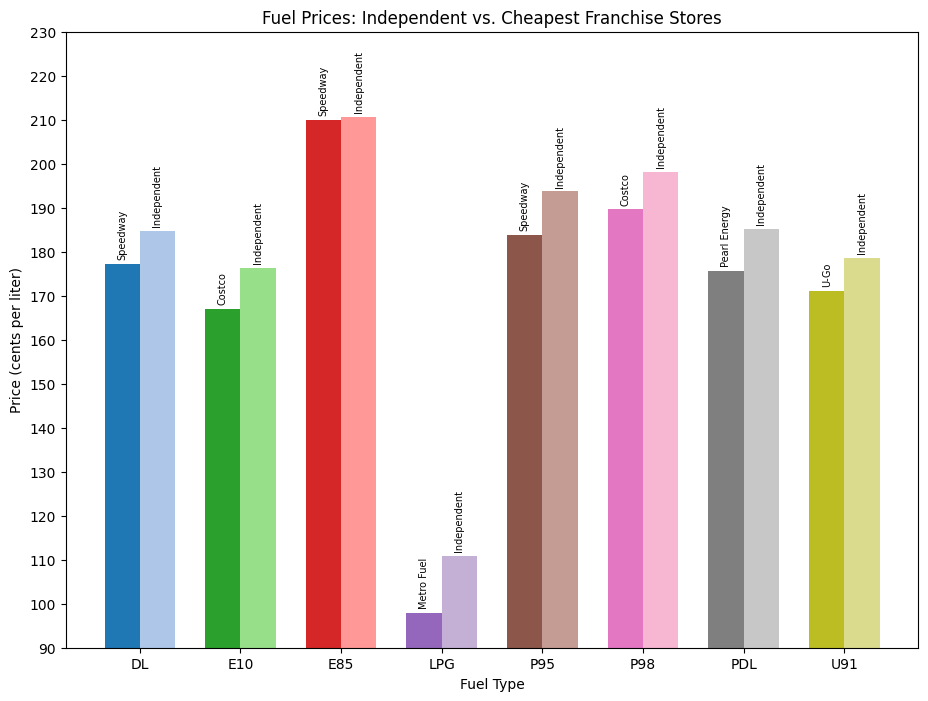

In [75]:
merged_df = min_fuel_df.merge(independent_avg_df, on="FuelCode", suffixes=("_Other", "_Independent"))
merged_df = merged_df.sort_values("FuelCode")
x = np.arange(len(merged_df))  
width = 0.35  

fig, ax = plt.subplots(figsize=(11,8))
bars1 = []
bars2 = []
for i, fuel in enumerate(merged_df["FuelCode"]):
    color_other, color_independent = fuel_colors.get(fuel, ("#333333", "#999999"))  
    bars1.append(ax.bar(x[i] - width/2, merged_df.loc[i, "Price_Other"], width, color=color_other, label="Other Stores" if i == 0 else ""))
    bars2.append(ax.bar(x[i] + width/2, merged_df.loc[i, "Price_Independent"], width, color=color_independent, label="Independent" if i == 0 else ""))

# Adding text labels (Brand Names) on bars
for bar, brand in zip(bars1, merged_df["Brand_Other"]):
    ax.text(bar[0].get_x() + bar[0].get_width()/2, bar[0].get_height()+1, brand, ha='center', va='bottom', fontsize=7, rotation=90)

for bar, brand in zip(bars2, merged_df["Brand_Independent"]):
    ax.text(bar[0].get_x() + bar[0].get_width()/2, bar[0].get_height()+1, brand, ha='center', va='bottom', fontsize=7, rotation=90)

# Labels, Title, and Customization
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Price (cents per liter)")
ax.set_title("Fuel Prices: Independent vs. Cheapest Franchise Stores")
ax.set_xticks(x)
ax.set_xticklabels(merged_df["FuelCode"])

# ax.legend()

ax.set_ylim(bottom=90)
ax.set_yticks(range(90, 231, 10))

# Show the chart
plt.show()

#### Question 9 ####

Assumption: 2826,2818 in Far West and Orana

In [76]:
data = {
    'Region': [
        'Sydney', 'Central Coast', 'Newcastle and Lake Macquarie', 'Illawarra',
        'Richmond - Tweed', 'Southern Highlands and Shoalhaven', 'Hunter Valley exc Newcastle',
        'Mid North Coast', 'Coffs Harbour - Grafton', 'Capital Region', 'Central West',
        'Riverina', 'New England and North West', 'Murray', 'Far West and Orana'
    ],
    'Postcode': [
        '2000 2006 2007 2008 2009 2010 2011 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045 2046 2047 2048 2049 2050 2052 2060 2061 2062 2063 2064 2065 2066 2067 2068 2069 2070 2071 2072 2073 2074 2075 2076 2077 2079 2080 2081 2082 2083 2084 2085 2086 2087 2088 2089 2090 2092 2093 2094 2095 2096 2097 2099 2100 2101 2102 2103 2104 2105 2106 2107 2108 2109 2110 2111 2112 2113 2114 2115 2116 2117 2118 2119 2120 2121 2122 2123 2125 2126 2127 2128 2129 2130 2131 2132 2133 2134 2135 2136 2137 2138 2139 2140 2141 2142 2143 2144 2145 2146 2147 2148 2150 2151 2152 2153 2154 2155 2156 2157 2158 2159 2160 2161 2162 2163 2164 2165 2166 2167 2168 2170 2171 2172 2173 2174 2175 2176 2177 2178 2179 2190 2191 2192 2193 2194 2195 2196 2197 2198 2199 2200 2203 2204 2205 2206 2207 2208 2209 2210 2211 2212 2213 2214 2216 2217 2218 2219 2220 2221 2222 2223 2224 2225 2226 2227 2228 2229 2230 2231 2232 2233 2234 2555 2556 2557 2558 2559 2560 2563 2564 2565 2566 2567 2568 2569 2570 2571 2572 2573 2574 2745 2747 2748 2749 2750 2752 2753 2754 2755 2756 2757 2758 2759 2760 2761 2762 2763 2765 2766 2767 2768 2769 2770 2773 2774 2775 2776 2777 2778 2779 2780 2782 2783 2784 2785 2786 2787 2790',
        '2083 2250 2251 2256 2257 2258 2259 2260 2261 2262 2263 2775',
        '2259 2264 2265 2267 2278 2280 2281 2282 2283 2284 2285 2286 2287 2289 2290 2291 2292 2293 2294 2295 2296 2297 2298 2299 2300 2302 2303 2304 2305 2306 2307 2308 2318 2322 2323',
        '2500 2502 2505 2506 2508 2515 2516 2517 2518 2519 2522 2525 2526 2527 2528 2529 2530 2533 2534 2535 2560 2577',
        '2469 2470 2471 2472 2473 2474 2475 2476 2477 2478 2479 2480 2481 2482 2483 2484 2485 2486 2487 2488 2489 2490',
        '2533 2535 2536 2538 2539 2540 2541 2571 2575 2576 2577 2578 2579 2622',
        '2250 2311 2312 2314 2315 2316 2317 2318 2319 2320 2321 2322 2323 2324 2325 2326 2327 2328 2329 2330 2331 2333 2334 2335 2336 2337 2338 2420 2421 2850',
        '2312 2324 2415 2420 2422 2423 2424 2425 2426 2427 2428 2429 2430 2431 2439 2440 2441 2443 2444 2445 2446 2447 2448 2449 2898',
        '2370 2441 2448 2449 2450 2452 2453 2454 2455 2456 2460 2462 2463 2464 2465 2466 2469',
        '2536 2537 2539 2545 2546 2548 2549 2550 2551 2579 2580 2581 2582 2583 2584 2585 2586 2587 2594 2611 2618 2619 2620 2621 2622 2623 2625 2626 2627 2628 2629 2630 2631 2632 2633 2666 2726 2787 2794 2803 2807 2808 2900',
        '2329 2580 2583 2594 2665 2666 2668 2669 2671 2672 2721 2785 2786 2787 2790 2791 2792 2793 2794 2795 2797 2798 2799 2800 2804 2805 2806 2807 2808 2809 2810 2823 2825 2844 2845 2846 2847 2848 2849 2850 2852 2864 2865 2866 2867 2868 2869 2870 2871 2873 2874 2875 2876 2877',
        '2588 2590 2594 2611 2624 2629 2640 2642 2644 2645 2649 2650 2651 2652 2653 2655 2656 2658 2661 2663 2665 2666 2668 2669 2675 2678 2680 2681 2700 2701 2702 2703 2705 2706 2707 2711 2720 2722 2725 2727 2729 2730 3707 3709',
        '2338 2339 2340 2341 2342 2343 2344 2345 2346 2347 2350 2351 2352 2353 2354 2355 2356 2358 2359 2360 2361 2365 2369 2370 2371 2372 2379 2380 2381 2382 2386 2387 2388 2390 2397 2398 2399 2400 2401 2402 2403 2404 2405 2406 2408 2409 2410 2411 2453 2469 2475 2476 2833 4383 4385',
        '2640 2641 2642 2643 2644 2645 2646 2647 2648 2650 2658 2659 2660 2700 2707 2710 2711 2712 2713 2714 2715 2716 2717 2731 2732 2733 2734 2735 2736 2737 2738 2739 2878 3490 3494 3498 3501 3505 3549 3564 3579 3585 3586 3639 3644 3691 3694 3709',
        '2357 2826 2818 2379 2381 2386 2387 2388 2395 2396 2648 2672 2820 2821 2822 2823 2824 2825 2827 2828 2829 2830 2831 2832 2833 2834 2835 2836 2839 2840 2842 2843 2850 2852 2866 2867 2868 2869 2877 2878 2879 2880 4493'
    ]
}

In [77]:
postcodes_df= pd.DataFrame(data)

# Split the postcodes string into a list of individual postcodes
postcodes_df['Postcode'] = postcodes_df['Postcode'].str.split()

# Explode the DataFrame to create a row for each postcode
postcodes_df = postcodes_df.explode('Postcode')

In [78]:
postcodes_df

,Region,Postcode
0,Sydney,2000
0,Sydney,2006
0,Sydney,2007
0,Sydney,2008
0,Sydney,2009
...,...,...
14,Far West and Orana,2877
14,Far West and Orana,2878
14,Far West and Orana,2879
14,Far West and Orana,2880


In [79]:
postcodes_df[postcodes_df.duplicated(subset=['Postcode'])]

,Region,Postcode
1,Central Coast,2083
1,Central Coast,2775
2,Newcastle and Lake Macquarie,2259
3,Illawarra,2560
5,Southern Highlands and Shoalhaven,2533
...,...,...
14,Far West and Orana,2867
14,Far West and Orana,2868
14,Far West and Orana,2869
14,Far West and Orana,2877


In [80]:
postcodes_df[postcodes_df['Postcode']=='2775'] 

,Region,Postcode
0,Sydney,2775
1,Central Coast,2775


In [81]:
postcodes_df = postcodes_df.drop_duplicates(subset='Postcode', keep='first')
postcodes_df

,Region,Postcode
0,Sydney,2000
0,Sydney,2006
0,Sydney,2007
0,Sydney,2008
0,Sydney,2009
...,...,...
14,Far West and Orana,2842
14,Far West and Orana,2843
14,Far West and Orana,2879
14,Far West and Orana,2880


In [82]:
dtype_map={
        'Postcode': 'int64',
        'Region': 'string',
}

In [83]:
postcodes_df=postcodes_df.astype(dtype_map)
postcodes_df.dtypes

Region      string[python]
Postcode             int64
dtype: object

In [84]:
df9 = df7.merge(postcodes_df,on=['Postcode'],how='left')
df9

,Name,Address,Suburb,Postcode,Brand,FuelType,PriceUpdatedDate,Price,Latitude,Longitude,PriceChangeAverage,PriceChangePrevious,Region
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01 02:17:21,205.9,-33.8833,151.1167,1.88,0.0,Sydney
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01 02:18:03,211.9,-33.9205,151.2552,0.79,0.0,Sydney
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01 02:18:03,187.9,-33.9205,151.2552,1.00,0.0,Sydney
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01 02:18:03,185.9,-33.9205,151.2552,-0.23,0.0,Sydney
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01 02:18:04,203.9,-33.9205,151.2552,0.82,0.0,Sydney
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59251,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31 18:59:20,198.9,-34.6487,150.2702,0.75,-1.0,Southern Highlands and Shoalhaven
59252,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31 18:59:20,201.9,-34.6487,150.2702,1.47,-1.0,Southern Highlands and Shoalhaven
59253,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31 19:11:20,198.9,-34.6487,150.2702,0.75,-1.0,Southern Highlands and Shoalhaven
59254,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31 19:11:20,201.9,-34.6487,150.2702,1.47,-1.0,Southern Highlands and Shoalhaven


In [85]:
df9[df9.isnull().any(axis=1)]

,Name,Address,Suburb,Postcode,Brand,FuelType,PriceUpdatedDate,Price,Latitude,Longitude,PriceChangeAverage,PriceChangePrevious,Region


In [86]:
df9['PriceUpdatedDate']= df9['PriceUpdatedDate'].apply(truncate_date)
df9

,Name,Address,Suburb,Postcode,Brand,FuelType,PriceUpdatedDate,Price,Latitude,Longitude,PriceChangeAverage,PriceChangePrevious,Region
0,Shell Croydon,"418-424 LIVERPOOL RD, CROYDON NSW 2132",CROYDON,2132,Shell,P98,2025-01-01,205.9,-33.8833,151.1167,1.88,0.0,Sydney
1,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P98,2025-01-01,211.9,-33.9205,151.2552,0.79,0.0,Sydney
2,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,U91,2025-01-01,187.9,-33.9205,151.2552,1.00,0.0,Sydney
3,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,E10,2025-01-01,185.9,-33.9205,151.2552,-0.23,0.0,Sydney
4,Ampol Foodary Coogee,"146-148 COOGEE BAY RD, COOGEE NSW 2034",COOGEE,2034,Ampol,P95,2025-01-01,203.9,-33.9205,151.2552,0.82,0.0,Sydney
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59251,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,DL,2025-01-31,198.9,-34.6487,150.2702,0.75,-1.0,Southern Highlands and Shoalhaven
59252,BP Marulan Northbound T/S,"Hume Highway, Marulan North NSW 2579",MARULAN NORTH,2579,BP,PDL,2025-01-31,201.9,-34.6487,150.2702,1.47,-1.0,Southern Highlands and Shoalhaven
59253,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,DL,2025-01-31,198.9,-34.6487,150.2702,0.75,-1.0,Southern Highlands and Shoalhaven
59254,BP Marulan Southbound T/S,"Hume Highway, Marulan South NSW 2579",MARULAN SOUTH,2579,BP,PDL,2025-01-31,201.9,-34.6487,150.2702,1.47,-1.0,Southern Highlands and Shoalhaven


In [87]:
daily_station_df1=df9.groupby(['Name','FuelType','PriceUpdatedDate']).agg({
    'Price': 'mean',
    'Postcode': 'first',
    'Region':'first'
}).round(2)
daily_station_df1

Price  Postcode         Region
Name              FuelType PriceUpdatedDate                                
7 Express Carlton E10      2025-01-01        169.9      2216         Sydney
                           2025-01-25        175.9      2216         Sydney
                  P95      2025-01-02        191.9      2216         Sydney
                           2025-01-25        197.9      2216         Sydney
                  PDL      2025-01-14        175.9      2216         Sydney
...                                            ...       ...            ...
shell cromer      U91      2025-01-20        178.9      2099         Sydney
                           2025-01-21        172.9      2099         Sydney
shell long jetty  E10      2025-01-01        175.9      2261  Central Coast
                  P98      2025-01-01        197.9      2261  Central Coast
                  U91      2025-01-01        177.9      2261  Central Coast

[44084 rows x 3 columns]

In [88]:
daily_postcode_df1=daily_station_df1.groupby(['Postcode','FuelType','PriceUpdatedDate']).agg({
    'Price': 'mean',
    'Region':'first'
}).round(2)
daily_postcode_df1

Price                      Region
Postcode FuelType PriceUpdatedDate                                   
2007     DL       2025-01-25        199.9                      Sydney
                  2025-01-28        196.9                      Sydney
                  2025-01-29        195.9                      Sydney
         E10      2025-01-02        189.9                      Sydney
                  2025-01-03        188.9                      Sydney
...                                   ...                         ...
2880     U91      2025-01-31        184.9          Far West and Orana
4383     DL       2025-01-26        194.9  New England and North West
         E10      2025-01-26        186.9  New England and North West
         P98      2025-01-26        210.9  New England and North West
         U91      2025-01-26        188.9  New England and North West

[24389 rows x 2 columns]

In [89]:
avg_postcode_df1=daily_postcode_df1.groupby(['Postcode','FuelType']).agg({
    'Price': 'mean',
    'Region':'first'
}).round(2)
avg_postcode_df1

Price                      Region
Postcode FuelType                                    
2007     DL        197.57                      Sydney
         E10       177.96                      Sydney
         P95       194.95                      Sydney
         P98       204.96                      Sydney
2008     P95       189.70                      Sydney
...                   ...                         ...
2880     U91       184.28          Far West and Orana
4383     DL        194.90  New England and North West
         E10       186.90  New England and North West
         P98       210.90  New England and North West
         U91       188.90  New England and North West

[2583 rows x 2 columns]

In [90]:
avg_Region_df1 = avg_postcode_df1.groupby(['Region','FuelType']).agg({
    'Price': 'mean',
}).round(2)
avg_Region_df1

Price
Region         FuelType        
Capital Region DL        193.52
               E10       185.17
               LPG       136.15
               P95       201.57
               P98       208.53
...                         ...
Sydney         LPG       107.27
               P95       200.59
               P98       207.76
               PDL       193.22
               U91       183.58

[108 rows x 1 columns]

In [91]:
df9['Region'].unique()

<StringArray>
[                           'Sydney',                'Far West and Orana',
                          'Riverina',      'Newcastle and Lake Macquarie',
                      'Central West',       'Hunter Valley exc Newcastle',
                     'Central Coast',        'New England and North West',
           'Coffs Harbour - Grafton', 'Southern Highlands and Shoalhaven',
                    'Capital Region',                         'Illawarra',
                            'Murray',                  'Richmond - Tweed',
                   'Mid North Coast']
Length: 15, dtype: string

In [92]:
df9['FuelType'].unique()

<StringArray>
['P98', 'U91', 'E10', 'P95', 'PDL', 'DL', 'LPG', 'E85']
Length: 8, dtype: string

In [93]:
region_fuelType = pd.MultiIndex.from_product(
    [df9['Region'].unique(), df9['FuelType'].unique()],
    names=['Region', 'FuelType']
)
region_fuelType

MultiIndex([(            'Sydney', 'P98'),
            (            'Sydney', 'U91'),
            (            'Sydney', 'E10'),
            (            'Sydney', 'P95'),
            (            'Sydney', 'PDL'),
            (            'Sydney',  'DL'),
            (            'Sydney', 'LPG'),
            (            'Sydney', 'E85'),
            ('Far West and Orana', 'P98'),
            ('Far West and Orana', 'U91'),
            ...
            (  'Richmond - Tweed', 'LPG'),
            (  'Richmond - Tweed', 'E85'),
            (   'Mid North Coast', 'P98'),
            (   'Mid North Coast', 'U91'),
            (   'Mid North Coast', 'E10'),
            (   'Mid North Coast', 'P95'),
            (   'Mid North Coast', 'PDL'),
            (   'Mid North Coast',  'DL'),
            (   'Mid North Coast', 'LPG'),
            (   'Mid North Coast', 'E85')],
           names=['Region', 'FuelType'], length=120)

In [94]:
avg_Region_df1=avg_Region_df1.reindex(region_fuelType , fill_value=0).reset_index()
avg_Region_df1

,Region,FuelType,Price
0,Sydney,P98,207.76
1,Sydney,U91,183.58
2,Sydney,E10,181.51
3,Sydney,P95,200.59
4,Sydney,PDL,193.22
...,...,...,...
115,Mid North Coast,P95,194.45
116,Mid North Coast,PDL,193.38
117,Mid North Coast,DL,192.29
118,Mid North Coast,LPG,126.65


In [96]:
pivot_df = avg_Region_df1.pivot(index='Region', columns='FuelType', values='Price')
pivot_df.drop(['E85'],axis=1,inplace=True)
pivot_df=pivot_df[['P98', 'U91', 'E10', 'P95', 'PDL', 'DL', 'LPG']]

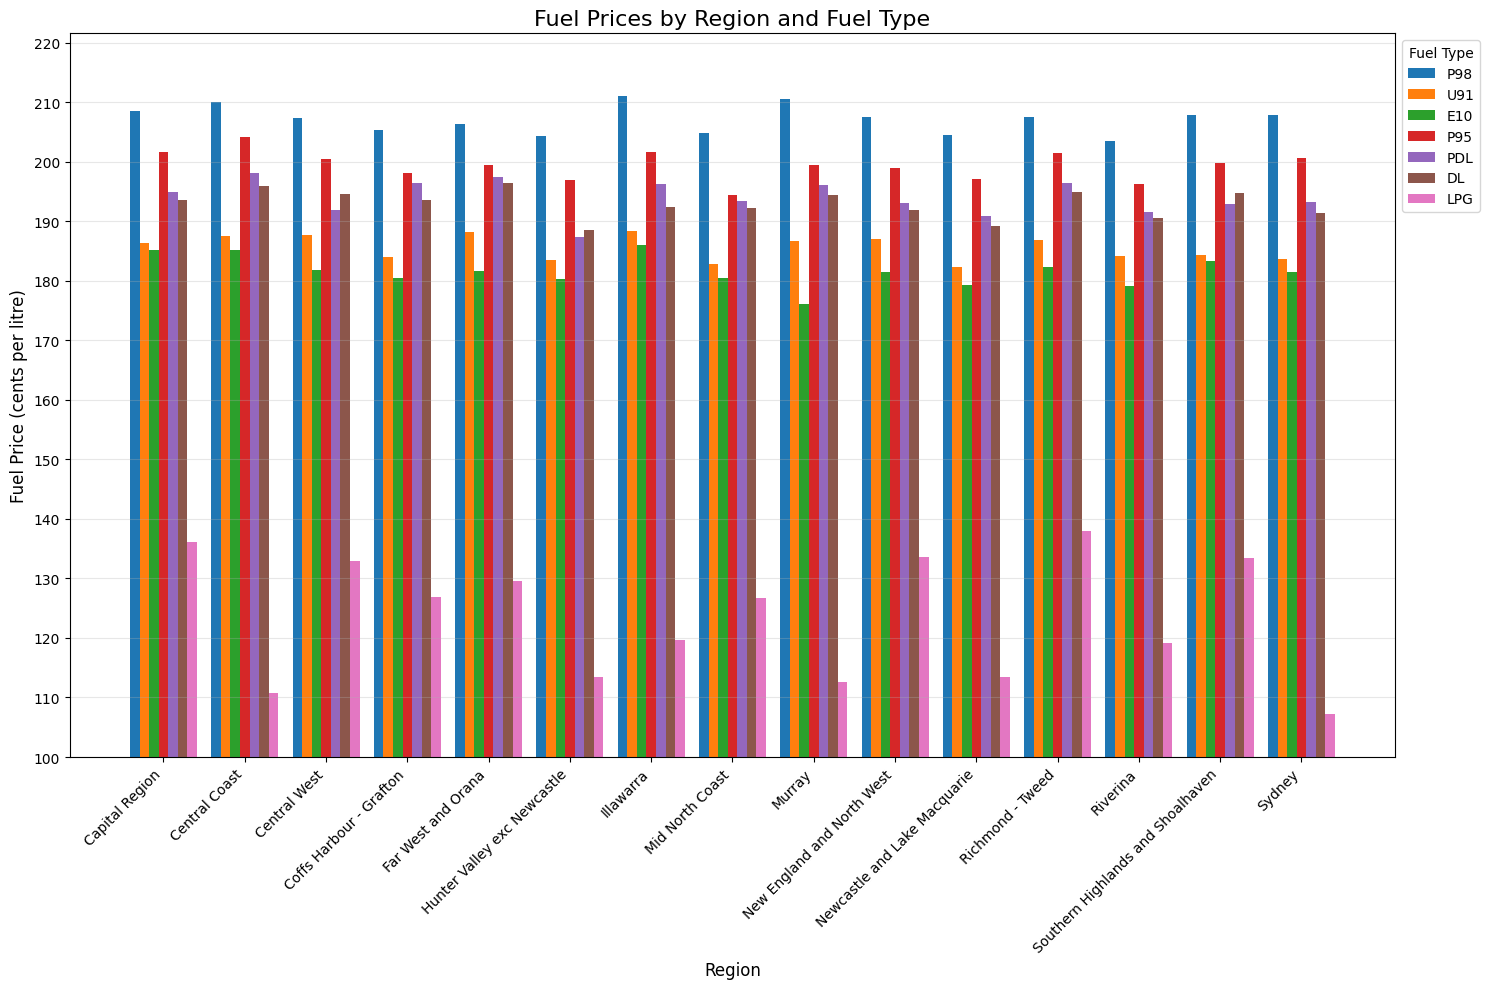

In [97]:
x = np.arange(len(pivot_df.index)) * 1.7  # Increased spacing between x locations
width = 0.2 # Bar width

fig, ax = plt.subplots(figsize=(15, 10))  # Increased figure width further

# Plot each fuel type as a separate group
for i, fuel_type in enumerate(pivot_df.columns):
    ax.bar(x + i * width, pivot_df[fuel_type], width, label=fuel_type)

# Customize the plot
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Fuel Price (cents per litre)', fontsize=12)
ax.set_title('Fuel Prices by Region and Fuel Type', fontsize=16)
ax.set_xticks(x + width * (len(pivot_df.columns) - 1) / 2)
ax.set_xticklabels(pivot_df.index, rotation=45, ha='right', fontsize=10)

ax.set_ylim(bottom=170)
ax.set_yticks(range(100, 221, 10))
ax.legend(title='Fuel Type', bbox_to_anchor=(1, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Increase spacing between x-ticks
plt.subplots_adjust(bottom=0.2, right=0.85)

plt.tight_layout()
plt.show()
